In [2]:
# =========================================================
# LIGHTWEIGHT PERSONALIZED SOM ANALYSIS
# COMPLETE JUPYTER STYLE SCRIPT
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# SETTINGS
# =========================================================

SOM_WIDTH = 22
SOM_HEIGHT = 22
SOM_NEURONS = SOM_WIDTH * SOM_HEIGHT

# =========================================================
# LOAD FILES
# =========================================================

weights_before = pd.read_csv(
    "weights_before.csv"
)

weights_after = pd.read_csv(
    "weights_after.csv"
)

hits_before = pd.read_csv(
    "bmu_hits_before.csv"
)

hits_after = pd.read_csv(
    "bmu_hits_after.csv"
)

print("Files loaded")

# =========================================================
# 1. TOPOLOGY / OCCUPANCY ANALYSIS
# =========================================================

used_before = np.sum(
    hits_before["hits"] > 0
)

used_after = np.sum(
    hits_after["hits"] > 0
)

print("\n===================================")
print(" BMU OCCUPANCY")
print("===================================")

print(
    f"Used BMUs BEFORE : {used_before}"
)

print(
    f"Used BMUs AFTER  : {used_after}"
)

compression = (
    1.0 -
    (used_after / used_before)
) * 100.0

print(
    f"Occupancy compression: "
    f"{compression:.2f}%"
)

# =========================================================
# 2. FEATURE DRIFT ANALYSIS
# =========================================================

print("\n===================================")
print(" FEATURE DRIFT")
print("===================================")

feature_names = {
    "f0": "HR",
    "f1": "RMSSD",
    "f2": "SC_PH",
    "f3": "SC_RR"
}

drift_results = {}

for feature in ["f0", "f1", "f2", "f3"]:

    before = np.zeros(
        (SOM_HEIGHT, SOM_WIDTH)
    )

    after = np.zeros(
        (SOM_HEIGHT, SOM_WIDTH)
    )

    # -----------------------------
    # BUILD FEATURE MAPS
    # -----------------------------

    for _, row in weights_before.iterrows():

        x = int(row["x"])
        y = int(row["y"])

        before[y, x] = row[feature]

    for _, row in weights_after.iterrows():

        x = int(row["x"])
        y = int(row["y"])

        after[y, x] = row[feature]

    # -----------------------------
    # DRIFT
    # -----------------------------

    drift = np.abs(after - before)

    mean_drift = drift.mean()
    max_drift = drift.max()

    drift_results[feature] = drift

    print(
        f"{feature_names[feature]}:"
    )

    print(
        f"  Mean drift : "
        f"{mean_drift:.8f}"
    )

    print(
        f"  Max drift  : "
        f"{max_drift:.8f}"
    )

# =========================================================
# 3. VISUALIZE BMU OCCUPANCY
# =========================================================

before_hits_map = np.zeros(
    (SOM_HEIGHT, SOM_WIDTH)
)

after_hits_map = np.zeros(
    (SOM_HEIGHT, SOM_WIDTH)
)

for _, row in hits_before.iterrows():

    x = int(row["x"])
    y = int(row["y"])

    before_hits_map[y, x] = row["hits"]

for _, row in hits_after.iterrows():

    x = int(row["x"])
    y = int(row["y"])

    after_hits_map[y, x] = row["hits"]

# -----------------------------
# BEFORE
# -----------------------------

plt.figure(figsize=(10,8))

plt.imshow(before_hits_map)

plt.title(
    "BMU Occupancy BEFORE Personalization"
)

plt.xlabel("SOM X")
plt.ylabel("SOM Y")

plt.colorbar()

plt.show()

# -----------------------------
# AFTER
# -----------------------------

plt.figure(figsize=(10,8))

plt.imshow(after_hits_map)

plt.title(
    "BMU Occupancy AFTER Personalization"
)

plt.xlabel("SOM X")
plt.ylabel("SOM Y")

plt.colorbar()

plt.show()

# =========================================================
# 4. FEATURE DRIFT VISUALIZATION
# =========================================================

for feature in ["f0", "f1", "f2", "f3"]:

    plt.figure(figsize=(10,8))

    plt.imshow(
        drift_results[feature]
    )

    plt.title(
        f"{feature_names[feature]} Drift"
    )

    plt.xlabel("SOM X")
    plt.ylabel("SOM Y")

    plt.colorbar()

    plt.show()

# =========================================================
# 5. GLOBAL MODEL CHANGE
# =========================================================

all_before = []
all_after = []

for feature in ["f0", "f1", "f2", "f3"]:

    all_before.extend(
        weights_before[feature].values
    )

    all_after.extend(
        weights_after[feature].values
    )

all_before = np.array(all_before)
all_after = np.array(all_after)

global_change = np.mean(
    np.abs(all_after - all_before)
)

print("\n===================================")
print(" GLOBAL MODEL CHANGE")
print("===================================")

print(
    f"Mean global weight change: "
    f"{global_change:.8f}"
)

# =========================================================
# 6. SUMMARY
# =========================================================

print("\n===================================")
print(" SUMMARY")
print("===================================")

if global_change < 0.001:

    print(
        "Very small global adaptation"
    )

    print(
        "Topology strongly preserved"
    )

elif global_change < 0.01:

    print(
        "Moderate adaptation"
    )

    print(
        "Local participant adaptation detected"
    )

else:

    print(
        "Large adaptation detected"
    )

    print(
        "Potential topology deformation"
    )

print("\nAnalysis complete")

FileNotFoundError: [Errno 2] No such file or directory: 'weights_after.csv'

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# LOAD TRAJECTORIES
# ==========================================

before = pd.read_csv("trajectory_before8.csv")
after  = pd.read_csv("trajectory_after8.csv")

print("Before samples:", len(before))
print("After samples :", len(after))

# ==========================================
# PLOT TRAJECTORIES
# ==========================================

plt.figure(figsize=(12, 10))

# -----------------------------
# BEFORE
# -----------------------------

plt.plot(
    before["x"],
    before["y"],
    marker='o',
    linewidth=1,
    markersize=3,
    alpha=0.7,
    label="Before personalization"
)

# -----------------------------
# AFTER
# -----------------------------

plt.plot(
    after["x"],
    after["y"],
    marker='x',
    linewidth=1,
    markersize=3,
    alpha=0.7,
    label="After personalization"
)

# ==========================================
# STYLE
# ==========================================

plt.gca().invert_yaxis()

plt.title("SOM Trajectory Before vs After Personalization")

plt.xlabel("SOM X")
plt.ylabel("SOM Y")

plt.grid(True)

plt.legend()

plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# LOAD FILES
# ==========================================================

traj_before = pd.read_csv("trajectory_before8.csv")
traj_after  = pd.read_csv("trajectory_after8.csv")

hits_before = pd.read_csv("bmu_hits_before8.csv")
hits_after  = pd.read_csv("bmu_hits_after8.csv")

weights_before = pd.read_csv("weights_before8.csv")
weights_after  = pd.read_csv("weights_after8.csv")

print("Files loaded")

SOM_W = 22
SOM_H = 22

# ==========================================================
# 1. TRAJECTORIES
# ==========================================================

plt.figure(figsize=(12,10))

plt.plot(
    traj_before["x"],
    traj_before["y"],
    marker='o',
    linewidth=1,
    markersize=3,
    alpha=0.7,
    label="Before"
)

plt.plot(
    traj_after["x"],
    traj_after["y"],
    marker='x',
    linewidth=1,
    markersize=3,
    alpha=0.7,
    label="After"
)

plt.gca().invert_yaxis()

plt.title("SOM Trajectory Before vs After")
plt.xlabel("SOM X")
plt.ylabel("SOM Y")

plt.grid(True)
plt.legend()

plt.show()

# ==========================================================
# 2. BMU OCCUPANCY
# ==========================================================

before_grid = np.zeros((SOM_H, SOM_W))
after_grid  = np.zeros((SOM_H, SOM_W))

for _, row in hits_before.iterrows():
    before_grid[int(row["y"]), int(row["x"])] = row["hits"]

for _, row in hits_after.iterrows():
    after_grid[int(row["y"]), int(row["x"])] = row["hits"]

# ---------- BEFORE ----------

plt.figure(figsize=(10,8))

plt.imshow(before_grid)

plt.title("BMU Occupancy BEFORE")

plt.xlabel("SOM X")
plt.ylabel("SOM Y")

plt.colorbar()

plt.show()

# ---------- AFTER ----------

plt.figure(figsize=(10,8))

plt.imshow(after_grid)

plt.title("BMU Occupancy AFTER")

plt.xlabel("SOM X")
plt.ylabel("SOM Y")

plt.colorbar()

plt.show()

# ==========================================================
# 3. OCCUPANCY DIFFERENCE
# ==========================================================

diff_occ = after_grid - before_grid

plt.figure(figsize=(10,8))

plt.imshow(diff_occ)

plt.title("BMU Occupancy Difference (After - Before)")

plt.xlabel("SOM X")
plt.ylabel("SOM Y")

plt.colorbar()

plt.show()

# ==========================================================
# 4. WEIGHT DRIFT MAPS
# ==========================================================

features = ["HR", "RMSSD", "SC_PH", "SC_RR"]

for f in range(4):

    drift = (
        weights_after.iloc[:, f].values -
        weights_before.iloc[:, f].values
    )

    drift_grid = drift.reshape(SOM_H, SOM_W)

    plt.figure(figsize=(10,8))

    plt.imshow(drift_grid)

    plt.title(f"{features[f]} Drift (After - Before)")

    plt.xlabel("SOM X")
    plt.ylabel("SOM Y")

    plt.colorbar()

    plt.show()

# ==========================================================
# 5. FEATURE DRIFT STATISTICS
# ==========================================================

print("\n===================================")
print(" FEATURE DRIFT")
print("===================================")

for f in range(4):

    drift = np.abs(
        weights_after.iloc[:, f].values -
        weights_before.iloc[:, f].values
    )

    print(f"{features[f]}:")
    print("  Mean drift :", np.mean(drift))
    print("  Max drift  :", np.max(drift))

# ==========================================================
# 6. BMU OCCUPANCY STATS
# ==========================================================

used_before = np.sum(before_grid > 0)
used_after  = np.sum(after_grid > 0)

print("\n===================================")
print(" BMU OCCUPANCY")
print("===================================")

print("Used BMUs BEFORE :", used_before)
print("Used BMUs AFTER  :", used_after)

compression = (
    1.0 - (used_after / used_before)
) * 100.0

print(f"Occupancy compression: {compression:.2f}%")

# ==========================================================
# 7. TRANSITION DISTANCE ANALYSIS
# ==========================================================

def transition_lengths(df):

    dists = []

    for i in range(1, len(df)):

        dx = df.iloc[i]["x"] - df.iloc[i-1]["x"]
        dy = df.iloc[i]["y"] - df.iloc[i-1]["y"]

        d = np.sqrt(dx*dx + dy*dy)

        dists.append(d)

    return np.array(dists)

before_trans = transition_lengths(traj_before)
after_trans  = transition_lengths(traj_after)

print("\n===================================")
print(" TRANSITION ANALYSIS")
print("===================================")

print("Before mean transition:", np.mean(before_trans))
print("After mean transition :", np.mean(after_trans))

print("Before max transition :", np.max(before_trans))
print("After max transition  :", np.max(after_trans))

# ==========================================================
# 8. TRANSITION HISTOGRAM
# ==========================================================

plt.figure(figsize=(10,6))

plt.hist(
    before_trans,
    bins=20,
    alpha=0.6,
    label="Before"
)

plt.hist(
    after_trans,
    bins=20,
    alpha=0.6,
    label="After"
)

plt.title("Transition Distance Distribution")

plt.xlabel("BMU Transition Distance")
plt.ylabel("Count")

plt.legend()

plt.show()

# ==========================================================
# 9. CLUSTER TRAJECTORY
# ==========================================================

plt.figure(figsize=(14,4))

plt.plot(
    traj_before["cluster"],
    label="Before",
    linewidth=1
)

plt.plot(
    traj_after["cluster"],
    label="After",
    linewidth=1
)

plt.title("Cluster Trajectory Over Time")

plt.xlabel("Sample")
plt.ylabel("Cluster")

plt.yticks([0,1,2])

plt.legend()

plt.grid(True)

plt.show()

# ==========================================================
# 10. LOCALIZATION SCORE
# ==========================================================

center_x_before = np.mean(traj_before["x"])
center_y_before = np.mean(traj_before["y"])

center_x_after = np.mean(traj_after["x"])
center_y_after = np.mean(traj_after["y"])

spread_before = np.mean(
    np.sqrt(
        (traj_before["x"] - center_x_before)**2 +
        (traj_before["y"] - center_y_before)**2
    )
)

spread_after = np.mean(
    np.sqrt(
        (traj_after["x"] - center_x_after)**2 +
        (traj_after["y"] - center_y_after)**2
    )
)

print("\n===================================")
print(" LOCALIZATION")
print("===================================")

print("Spread BEFORE:", spread_before)
print("Spread AFTER :", spread_after)

if spread_after < spread_before:
    print("Trajectory became MORE localized")
else:
    print("Trajectory became MORE spread")

In [2]:
som_clusters = np.array([
   0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,
   1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,
   0,0,0,0,0,1,1,1,1,1,1,1,0,0,0,0,
   0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,
   1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,
   1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,
   0,0,0,0,0,1,1,1,1,1,1,1,1,1,0,0,
   0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,
   1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,2,
   2,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,
   0,0,0,0,2,2,2,2,1,1,1,1,1,1,1,1,
   0,0,0,0,0,0,0,0,0,2,2,2,2,2,1,1,
   1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,2,
   2,2,2,2,2,1,1,1,1,1,1,1,0,0,0,0,
   0,0,0,0,2,2,2,2,2,2,2,2,1,1,1,1,
   1,1,0,0,0,0,0,0,0,0,2,2,2,2,2,2,
   2,2,1,1,1,1,1,1,0,0,0,0,0,0,0,2,
   2,2,2,2,2,2,2,2,2,1,1,1,1,1,0,0,
   0,0,0,0,0,2,2,2,2,2,2,2,2,2,2,2,
   1,1,1,1,0,0,0,0,0,0,0,2,2,2,2,2,
   2,2,2,2,2,2,2,2,1,1,0,0,0,0,0,0,
   2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
   0,0,0,0,0,0,2,2,2,2,2,2,2,2,2,2,
   2,2,2,2,2,2,0,0,0,0,0,2,2,2,2,2,
   2,2,2,2,2,2,2,2,2,2,2,2,0,0,0,0,
   0,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
   2,2,0,0,0,0,2,2,2,2,2,2,2,2,2,2,
   2,2,2,2,2,2,2,2,0,0,0,0,2,2,2,2,
   2,2,2,2,2,2,2,2,2,2,2,2,2,2,0,0,
   0,0,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
   2,2,2,2, ])

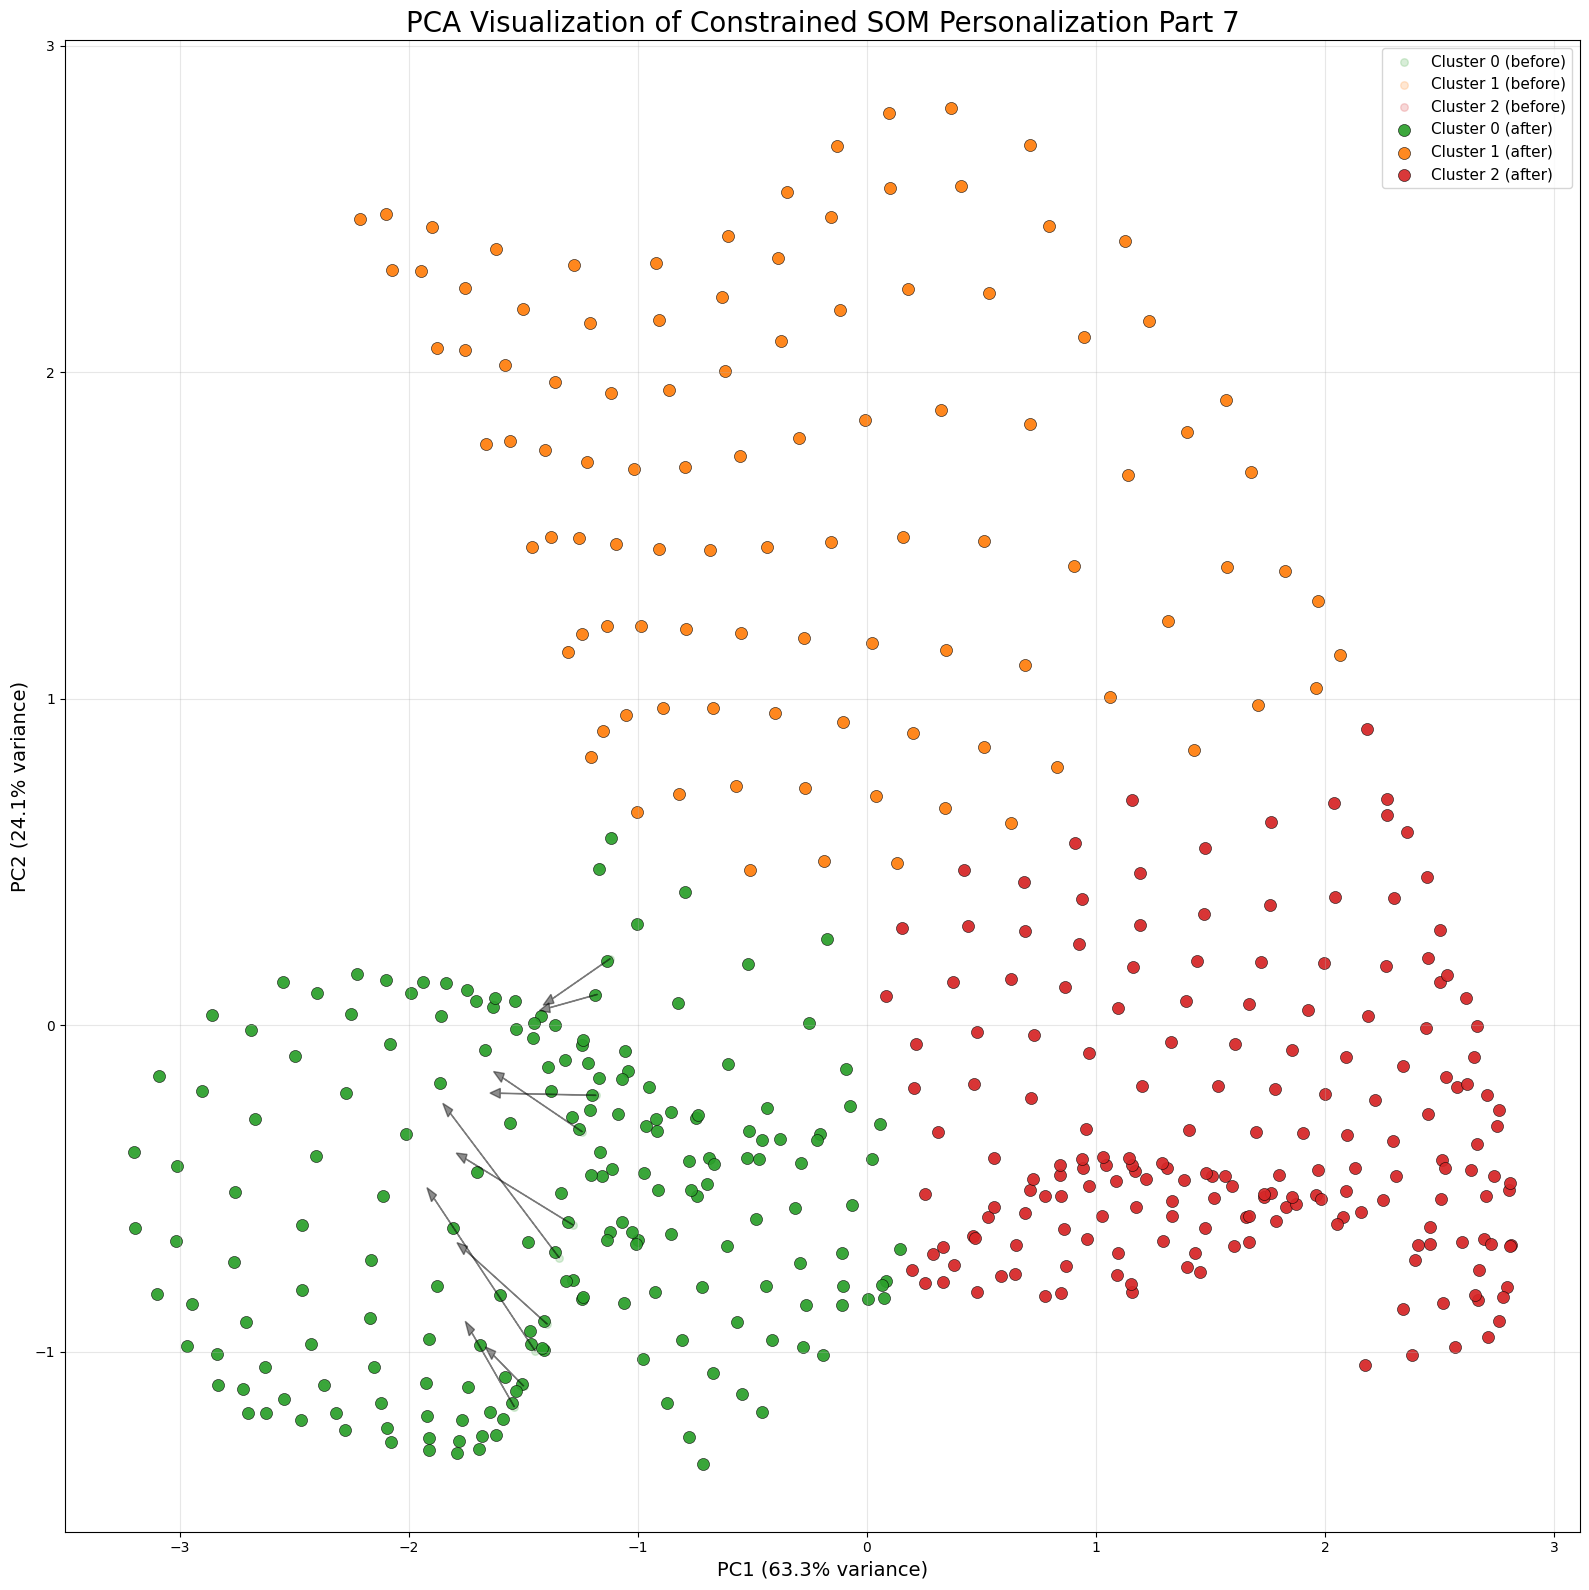

GLOBAL DRIFT ANALYSIS PART 7
Mean drift : 0.000281
Median drift : 0.000003
Max drift : 0.010238


DRIFT PER CLUSTER
             mean    median       std       max
cluster                                        
0        0.000545  0.000053  0.001521  0.010238
1        0.000255  0.000133  0.000345  0.001902
2        0.000021  0.000000  0.000079  0.000597


PCA EXPLAINED VARIANCE
PC1: 0.6333
PC2: 0.2413
Total: 0.8746


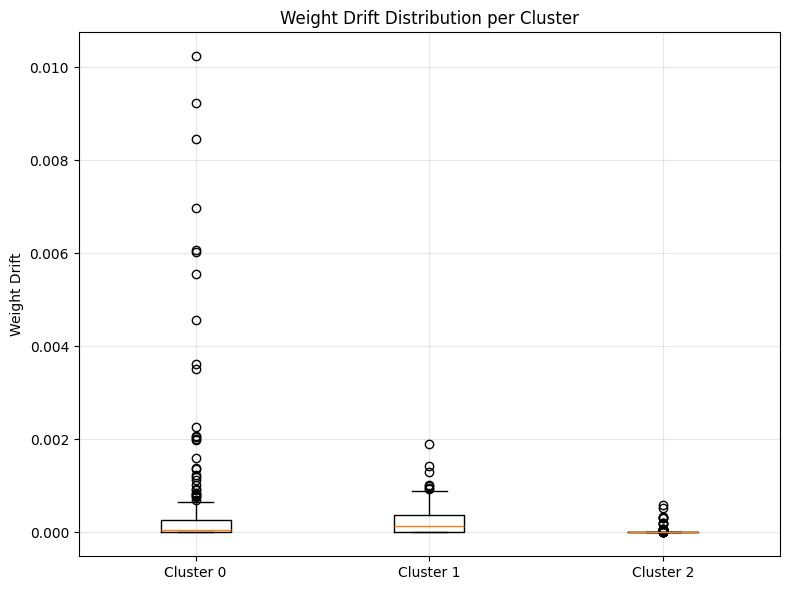

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# =====================================================
# LOAD WEIGHTS
# =====================================================

file_path_before = "../data/updated_model_files_analys/weights_before8.csv"
file_path_after  = "../data/updated_model_files_analys/weights_after8.csv"

before = pd.read_csv(file_path_before)
after  = pd.read_csv(file_path_after)

# =====================================================
# FEATURE COLUMNS
# =====================================================

feature_cols = ["f0", "f1", "f2", "f3"]

X_before = before[feature_cols].values
X_after  = after[feature_cols].values

# =====================================================
# ADD STATIC CLUSTERS
# (som_clusters already created in another cell)
# =====================================================

before["cluster"] = som_clusters
after["cluster"]  = som_clusters

clusters = np.array(som_clusters)

# =====================================================
# CALCULATE WEIGHT DRIFT
# =====================================================

drift = np.linalg.norm(
    X_after - X_before,
    axis=1
)

before["drift"] = drift

# =====================================================
# COMBINE FOR PCA
# =====================================================

X_combined = np.vstack([X_before, X_after])

# =====================================================
# SCALE
# =====================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_combined)

# =====================================================
# PCA
# =====================================================

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

before_pca = X_pca[:len(X_before)]
after_pca  = X_pca[len(X_before):]

# =====================================================
# COLOR MAP
# =====================================================

cluster_colors = {
    0: "tab:green",
    1: "tab:orange",
    2: "tab:red"
}

# =====================================================
# FIGURE
# =====================================================

plt.figure(figsize=(16, 16))

# =====================================================
# PLOT BEFORE POINTS
# =====================================================

for cluster in np.unique(clusters):

    idx = clusters == cluster

    plt.scatter(
        before_pca[idx, 0],
        before_pca[idx, 1],
        color=cluster_colors[cluster],
        s=30,
        alpha=0.18,
        label=f"Cluster {cluster} (before)"
    )

# =====================================================
# PLOT AFTER POINTS
# =====================================================

for cluster in np.unique(clusters):

    idx = clusters == cluster

    plt.scatter(
        after_pca[idx, 0],
        after_pca[idx, 1],
        color=cluster_colors[cluster],
        edgecolors="black",
        linewidths=0.4,
        s=75,
        alpha=0.92,
        label=f"Cluster {cluster} (after)"
    )

# =====================================================
# DRAW ONLY IMPORTANT ADAPTATION ARROWS
# =====================================================

scale = 25

for i in range(len(before_pca)):

    # skip tiny movements
    if drift[i] < 0.003:
        continue

    dx = (
        after_pca[i, 0] -
        before_pca[i, 0]
    ) * scale

    dy = (
        after_pca[i, 1] -
        before_pca[i, 1]
    ) * scale

    plt.arrow(
        before_pca[i, 0],
        before_pca[i, 1],
        dx,
        dy,
        color="black",
        alpha=0.45,
        linewidth=1.0,
        head_width=0.03,
        length_includes_head=True
    )

# =====================================================
# LABELS
# =====================================================

plt.title(
    "PCA Visualization of Constrained SOM Personalization Part 7",
    fontsize=20
)

plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)",
    fontsize=14
)

plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)",
    fontsize=14
)

plt.grid(True, alpha=0.3)

# =====================================================
# CLEAN LEGEND
# =====================================================

handles, labels = plt.gca().get_legend_handles_labels()

unique = dict(zip(labels, handles))

plt.legend(
    unique.values(),
    unique.keys(),
    fontsize=11
)

plt.tight_layout()

plt.show()

# =====================================================
# DRIFT ANALYSIS
# =====================================================

print("=" * 60)
print("GLOBAL DRIFT ANALYSIS PART 7")
print("=" * 60)

print(f"Mean drift : {np.mean(drift):.6f}")
print(f"Median drift : {np.median(drift):.6f}")
print(f"Max drift : {np.max(drift):.6f}")

# =====================================================
# DRIFT PER CLUSTER
# =====================================================

cluster_stats = before.groupby(
    "cluster"
)["drift"].agg([
    "mean",
    "median",
    "std",
    "max"
])

print("\n")
print("=" * 60)
print("DRIFT PER CLUSTER")
print("=" * 60)

print(cluster_stats)

# =====================================================
# EXPLAINED VARIANCE
# =====================================================

print("\n")
print("=" * 60)
print("PCA EXPLAINED VARIANCE")
print("=" * 60)

print(
    f"PC1: {pca.explained_variance_ratio_[0]:.4f}"
)

print(
    f"PC2: {pca.explained_variance_ratio_[1]:.4f}"
)

print(
    f"Total: {np.sum(pca.explained_variance_ratio_):.4f}"
)

# =====================================================
# OPTIONAL: BOXPLOT DRIFT PER CLUSTER
# =====================================================

plt.figure(figsize=(8, 6))

data_to_plot = [
    before[before["cluster"] == c]["drift"]
    for c in sorted(before["cluster"].unique())
]

plt.boxplot(data_to_plot)

plt.xticks(
    [1,2,3],
    ["Cluster 0", "Cluster 1", "Cluster 2"]
)

plt.ylabel("Weight Drift")

plt.title("Weight Drift Distribution per Cluster")

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

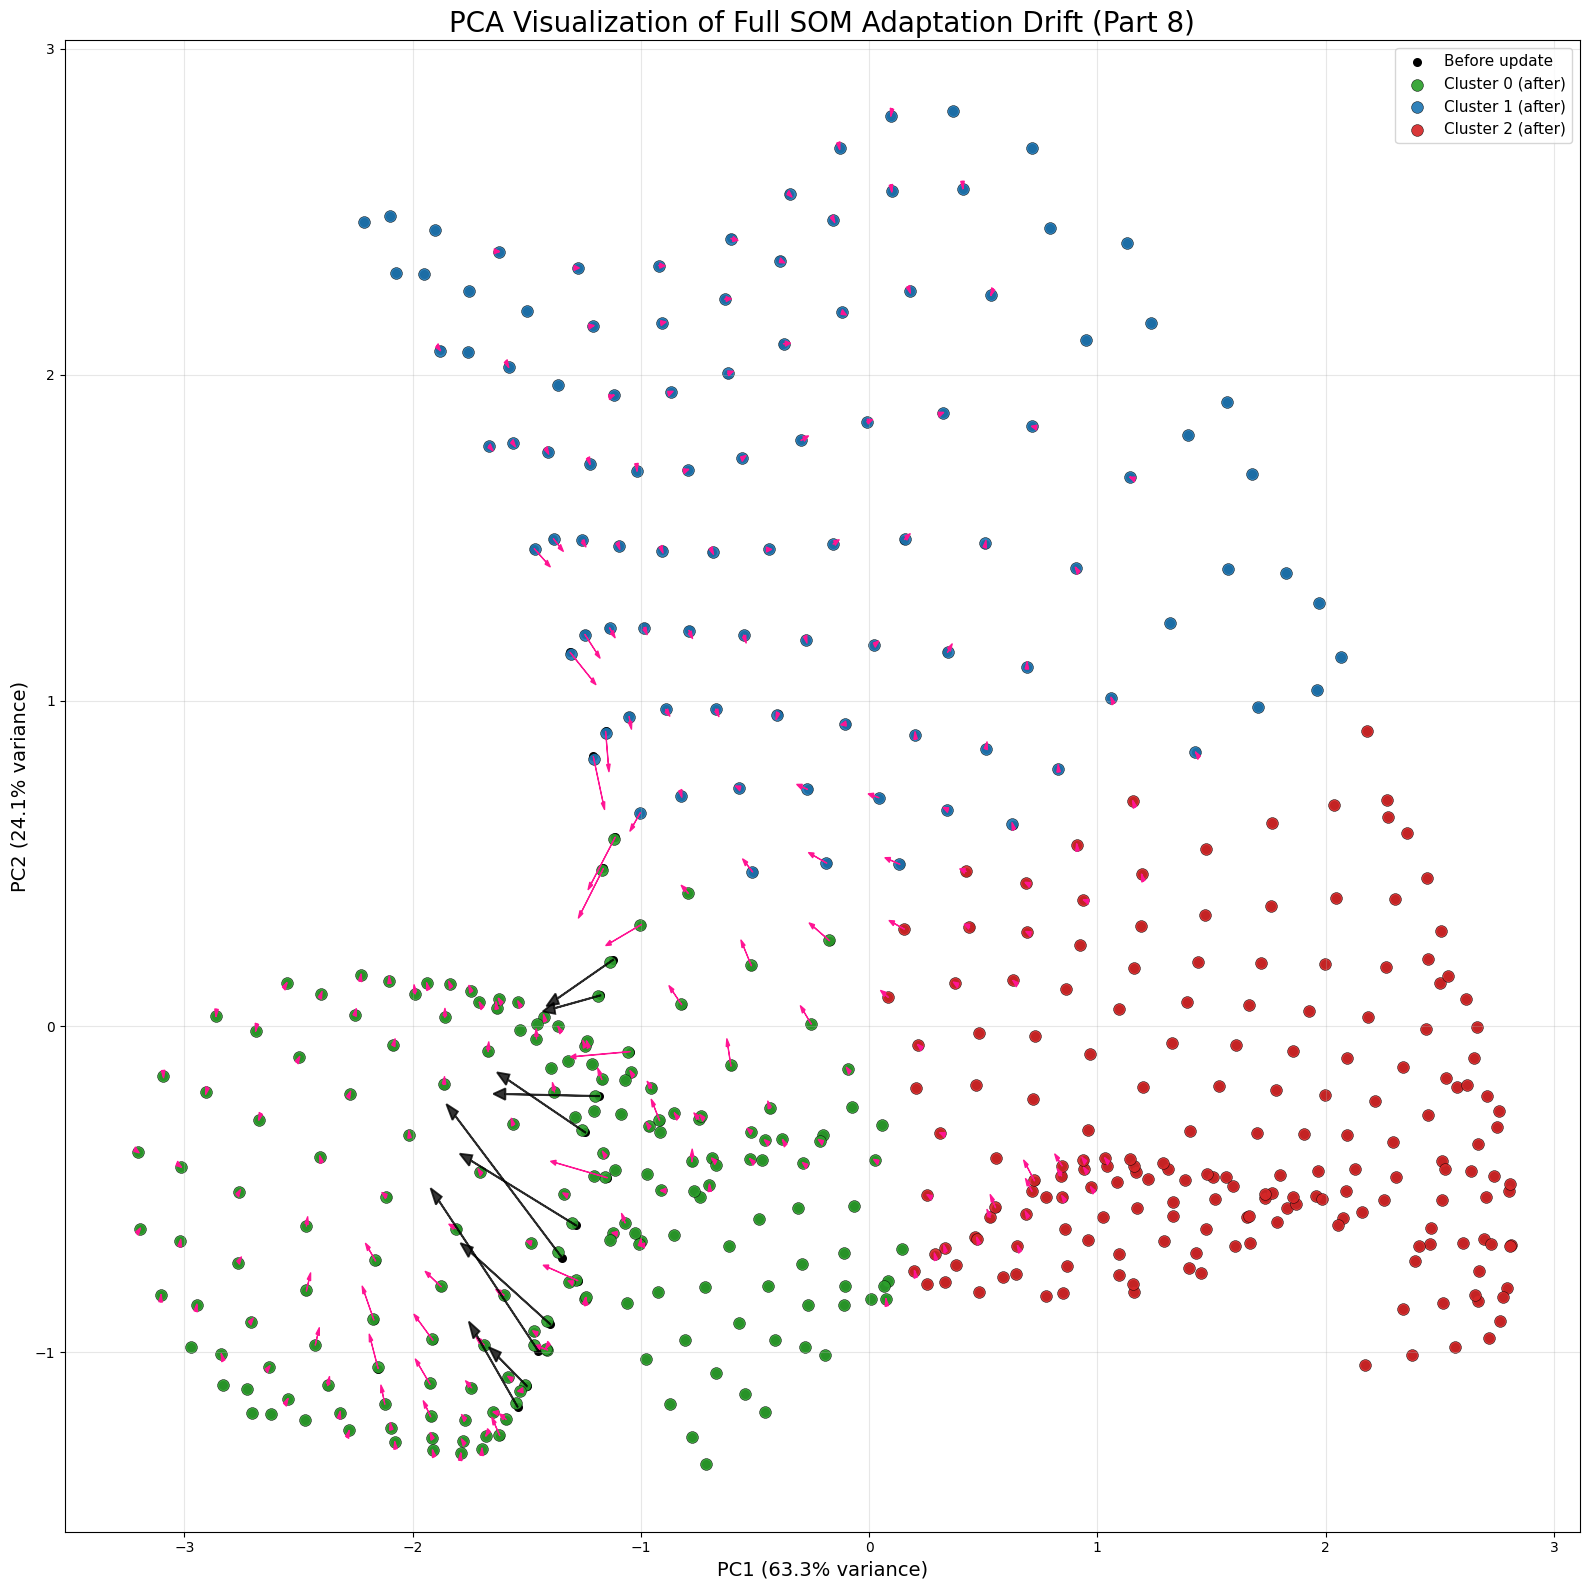

In [15]:
# =====================================================
# VISUALIZE ALL ADAPTATION ARROWS
# BEFORE = SOLID BLACK
# AFTER = CLUSTER COLORS
# SMALL DRIFT = YELLOW
# LARGE DRIFT = BLACK
# =====================================================

plt.figure(figsize=(16, 16))

# =====================================================
# UPDATED COLOR MAP
# =====================================================

cluster_colors = {
    0: "tab:green",
    1: "tab:blue",
    2: "tab:red"
}

# =====================================================
# PLOT BEFORE POINTS (SOLID BLACK)
# =====================================================

plt.scatter(
    before_pca[:, 0],
    before_pca[:, 1],
    color="black",
    s=30,
    alpha=1.0,
    label="Before update"
)

# =====================================================
# PLOT AFTER POINTS
# =====================================================

for cluster in np.unique(clusters):

    idx = clusters == cluster

    plt.scatter(
        after_pca[idx, 0],
        after_pca[idx, 1],
        color=cluster_colors[cluster],
        edgecolors="black",
        linewidths=0.35,
        s=72,
        alpha=0.92,
        label=f"Cluster {cluster} (after)"
    )

# =====================================================
# DRAW ALL ARROWS
# =====================================================

scale = 25

for i in range(len(before_pca)):

    dx = (
        after_pca[i, 0] -
        before_pca[i, 0]
    ) * scale

    dy = (
        after_pca[i, 1] -
        before_pca[i, 1]
    ) * scale

    # =================================================
    # LARGE DRIFT = BLACK
    # =================================================

    if drift[i] >= 0.003:

        plt.arrow(
            before_pca[i, 0],
            before_pca[i, 1],
            dx,
            dy,
            color="black",
            alpha=0.80,
            linewidth=1.3,
            head_width=0.035,
            length_includes_head=True,
            zorder=10
        )

    # =================================================
    # SMALL DRIFT = YELLOW
    # =================================================

    elif drift[i] > 0:

        plt.arrow(
            before_pca[i, 0],
            before_pca[i, 1],
            dx,
            dy,
            color="deeppink",
            alpha=1.0,
            linewidth=0.85,
            head_width=0.016,
            length_includes_head=True,
            zorder=2
        )

# =====================================================
# LABELS
# =====================================================

plt.title(
    "PCA Visualization of Full SOM Adaptation Drift (Part 8)",
    fontsize=20
)

plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)",
    fontsize=14
)

plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)",
    fontsize=14
)

plt.grid(True, alpha=0.3)

# =====================================================
# CLEAN LEGEND
# =====================================================

handles, labels = plt.gca().get_legend_handles_labels()

unique = dict(zip(labels, handles))

plt.legend(
    unique.values(),
    unique.keys(),
    fontsize=11
)

plt.tight_layout()

plt.show()